In [1]:
# pip install pandas 
# pip install seaborn matplotlib statsmodels
# pip install spicy jinja2

In [2]:
from pathlib import Path
import pandas as pd

In [3]:
index_path = Path('../data/2025-10-29/index.json')

df0 = pd.read_json(str(index_path), orient='table')

df0

,edition,volume,page,title,labels,refs,vocd,msttr,mtld,chars,words,semantic_search-label,semantic_search-score,in_x
eb09/XML/y24/kp-eb0924-074303-0788m.xml,9,24,743,YEOVIL,"[Boroughs, Manors, Church, Men, Baptists, Chri...","[fasttopic:836750, fasttopic:1007857, fasttopi...",58.195016,0.829474,51.385711,3012.0,507.0,NaN,NaN,NaN
eb09/XML/y24/kp-eb0924-073301-0778m.xml,9,24,733,"YAZD, or Yezd","[Jews, Towns, Ruins, Felt, Roads, Fires, Jews,...","[lcsh1910:b4x34mt4n, lcsh1910:b4hq3s746, lcsh1...",72.810015,0.850526,78.271792,3008.0,502.0,NaN,NaN,NaN
eb09/XML/y24/kp-eb0924-072803-0773m.xml,9,24,728,YANINA,[],[],0.000000,0.000000,3.000000,20.0,3.0,NaN,NaN,NaN
eb09/XML/y24/kp-eb0924-074101-0786m.xml,9,24,741,YENISEI,[],[],0.000000,0.000000,5.000000,36.0,5.0,NaN,NaN,NaN
eb09/XML/y24/kp-eb0924-072702-0772m.xml,9,24,727,YAM,"[India, England, China, Flowers, Yams, Tubers,...","[fastgeo:1210276, fastgeo:1219920, fastgeo:120...",88.778881,0.855385,90.270456,2084.0,345.0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
eb07/XML/v21/kp-eb0721-066204-0702.xml,7,21,662,VIZZINI,"[Islands, Mountains, Mountaineering, Islands, ...","[lcsh1910:b4kp7tx0f, lcsh1910:b43n20j3f, lcsh1...",38.978880,0.780000,38.092071,348.0,64.0,useful_arts,0.198982,NaN
eb07/XML/v21/kp-eb0721-064202-0682.xml,7,21,642,VICAR,"[Functions, Canonization, Law, Priests, Parish...","[lcsh1910:b4dv1cn3t, lcsh1910:b4x05xd69, lcsh1...",49.816387,0.800000,59.316514,393.0,67.0,sacred_history,0.396339,NaN
eb07/XML/v21/kp-eb0721-065104-0691.xml,7,21,651,VINA or Βιν,"[Vina, Kindness, Books, Research, Research, Ki...","[fasttopic:1167024, fasttopic:987598, fasttopi...",0.000000,0.840000,36.935519,244.0,40.0,philosophy,0.262852,NaN
eb07/XML/v21/kp-eb0721-060509-0643.xml,7,21,605,VERULAM,"[Life, Man, Queens, Courts, Heart, Coke, Tower...","[lcsh1910:b42j68511, lcsh1910:b4jw86m8z, lcsh1...",97.901880,0.888818,100.714770,46438.0,7942.0,philosophy,0.228531,NaN


In [4]:
df = df0[df0['words'] > 1000]

df = df[df['semantic_search-score'] > 0.0]

df = df[df['edition'] == 7]

cols_to_keep = {'mtld': 'ld', 'semantic_search-label': 'domain', 'words': 'words'}
df = df[cols_to_keep.keys()].rename(columns=cols_to_keep)

df

,ld,domain,words
eb07/XML/k12/kp-eb0712-075805-7656.xml,81.615409,useful_arts,1741.0
eb07/XML/k12/kp-eb0712-066211-6408.xml,54.979564,natural_science,9112.0
eb07/XML/k12/kp-eb0712-069201-6798.xml,91.962160,philosophy,1500.0
eb07/XML/k12/kp-eb0712-068901-6759.xml,85.598798,fine_arts,1194.0
eb07/XML/k12/kp-eb0712-072601-7240.xml,70.527932,useful_arts,2324.0
...,...,...,...
eb07/XML/v21/kp-eb0721-059911-0637.xml,75.775058,natural_science,5609.0
eb07/XML/v21/kp-eb0721-064802-0688.xml,97.946551,theology,2324.0
eb07/XML/v21/kp-eb0721-070001-0740.xml,83.038948,fine_arts,2404.0
eb07/XML/v21/kp-eb0721-065107-0691.xml,59.733728,civil_history,1288.0


In [5]:
summary = df.groupby('domain').agg(
    count=('ld', 'count'),
    variance=('ld', 'var'),
    std_dev=('ld', 'std'),
    mean_ld=('ld', 'mean'),
    median_words=('words', 'median')
)
summary

,count,variance,std_dev,mean_ld,median_words
domain,,,,,
civil_history,359,171.396508,13.091849,77.545028,2351.0
fine_arts,210,153.568000,12.392256,80.151268,2354.5
natural_history,135,221.871697,14.895358,76.366319,3338.0
natural_science,292,224.197887,14.973239,65.266758,6740.5
philosophy,168,185.026408,13.602441,76.213758,3201.5
sacred_history,212,137.417404,11.722517,72.880848,2254.5
theology,174,149.249308,12.216763,79.669036,2318.0
useful_arts,308,122.580375,11.071602,66.279831,2634.5


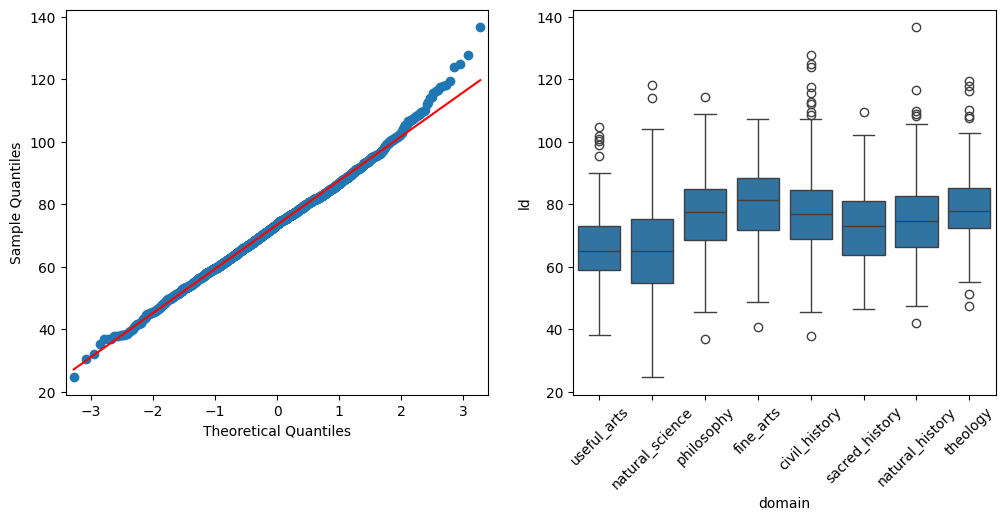

In [6]:
# google ai, 19/02/2026
'''To ensure your ANOVA results are valid, you should check for 
Normality (data follows a bell curve) 
and 
Homogeneity of Variance (all groups have similar spread)'''

import seaborn as sns
import matplotlib.pyplot as plt
# from scipy import stats
import statsmodels.api as sm

# 1. VISUAL: Q-Q Plot and Boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Q-Q Plots: Plot your data against a theoretical normal distribution. If the points fall along the diagonal line, the data is likely normal
sm.qqplot(df['ld'], line='s', ax=axes[0]) # Overall normality of residuals
# Compare the "whiskers" and box sizes across domains to see if the spread (variance) is similar
sns.boxplot(x='domain', y='ld', data=df, ax=axes[1])
plt.xticks(rotation=45)
plt.show()

In [7]:
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# 1. One-way ANOVA
# This "omnibus" test determines if there is any statistically significant difference among the means of your 8 domains 
model = ols('ld ~ C(domain)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("\nANOVA results:")
anova_table



ANOVA results:


,sum_sq,df,F,PR(>F)
C(domain),60063.740999,7.0,50.914912,1.405043e-66
Residual,311774.842156,1850.0,NaN,NaN


PR(>F) is the p-value. p < 0.05 means that "At least one domain has a significantly different mean LD."
"ANOVA does not tell you which domains differ — only that some do."

(copilot)

In [8]:
# Code by https://chat.mistral.ai/chat (19/02/2026)
from scipy.stats import f_oneway
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Assuming your dataframe is called 'df'
# Example data structure:
# df = pd.DataFrame({'domain': ['A', 'A', 'B', 'B', 'C', 'C'], 'ld': [1.2, 1.3, 1.5, 1.6, 1.1, 1.0]})

# Group the data by domain
grouped = df.groupby('domain')['ld'].apply(list)

# Perform one-way ANOVA
f_stat, p_value = f_oneway(*grouped)

print(f"F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

tukey = None

# If p-value < 0.05, perform post-hoc Tukey's HSD
if p_value < 0.05:
    # Tukey’s HSD (if ANOVA is significant):
    # This test shows which specific domains have significantly different means.
    # Look for pairs with reject=True and p-adj < 0.05.
    tukey = pairwise_tukeyhsd(df['ld'], df['domain'], alpha=0.05)
    print(tukey.summary())


F-statistic: 50.915, p-value: 0.0000
          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
     group1          group2     meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------
  civil_history       fine_arts   2.6062  0.288  -0.8159   6.0284  False
  civil_history natural_history  -1.1787 0.9862  -5.1557   2.7983  False
  civil_history natural_science -12.2783    0.0 -15.3825   -9.174   True
  civil_history      philosophy  -1.3313 0.9575  -5.0135   2.3509  False
  civil_history  sacred_history  -4.6642 0.0009  -8.0762  -1.2522   True
  civil_history        theology    2.124 0.6398  -1.5147   5.7627  False
  civil_history     useful_arts -11.2652    0.0 -14.3246  -8.2057   True
      fine_arts natural_history  -3.7849 0.1414  -8.1304   0.5605  False
      fine_arts natural_science -14.8845    0.0 -18.4486 -11.3204   True
      fine_arts      philosophy  -3.9375 0.0673  -8.0149   0.1399  False
      fine_art

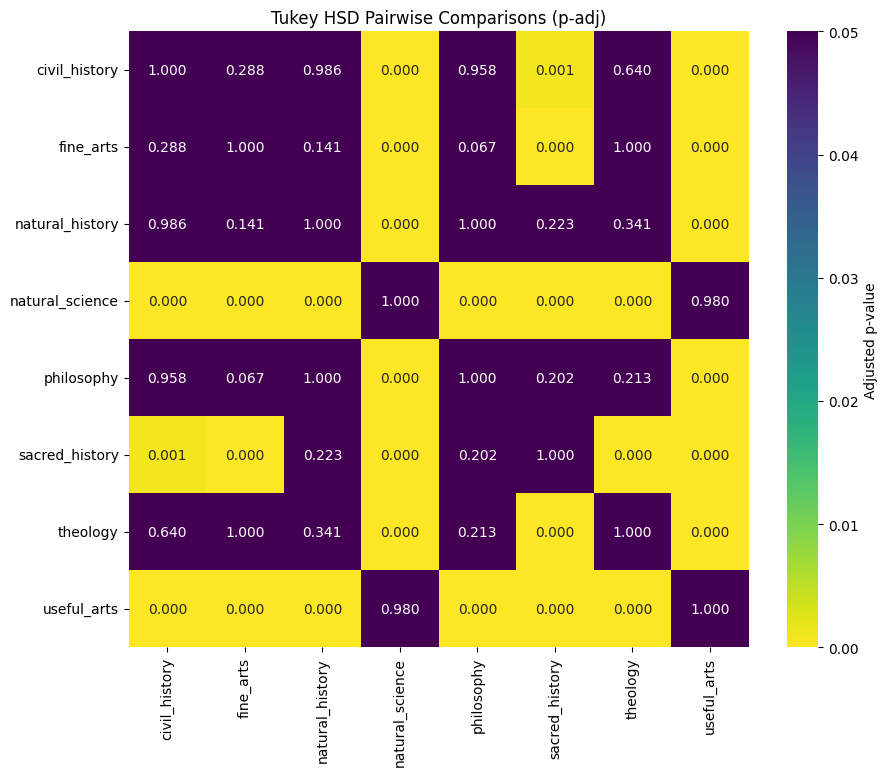

In [9]:
# 1. Access the p-values array directly (most robust method)
# 'tukey.pvalues' is a flat array of p-values in the same order 
# as the pairwise comparisons in the summary table.
p_vals = tukey.pvalues
groups = tukey.groupsunique

# 2. Create the symmetric matrix
# Initialize with 1.0 (non-significant)
p_matrix = pd.DataFrame(1.0, index=groups, columns=groups)

# 3. Map the flat p-values to the square matrix
# statsmodels iterates through combinations in a specific order:
# (Group 0 vs 1), (Group 0 vs 2), ..., (Group 1 vs 2), etc.
from itertools import combinations
for (i, j), p in zip(combinations(range(len(groups)), 2), p_vals):
    p_matrix.iloc[i, j] = p
    p_matrix.iloc[j, i] = p

# 4. Final Plotting
plt.figure(figsize=(10, 8))
sns.heatmap(p_matrix, 
            annot=True, 
            fmt=".3f", 
            cmap="viridis_r", 
            vmax=0.05,  # Saturated color for any p > 0.05
            cbar_kws={'label': 'Adjusted p-value'})

plt.title("Tukey HSD Pairwise Comparisons (p-adj)")
plt.show()
